In [2]:
%pip install torch torchvision timm

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import timm

from tqdm import tqdm

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Device: cpu


In [10]:
train_dir = "processed_dataset/train"
val_dir   = "processed_dataset/val"
test_dir  = "processed_dataset/test"

save_dir = "results"

os.makedirs(save_dir, exist_ok=True)

In [12]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [14]:
val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [16]:
train_dataset = ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = ImageFolder(
    val_dir,
    transform=val_transform
)

test_dataset = ImageFolder(
    test_dir,
    transform=val_transform
)

In [ ]:
batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [20]:
class_names = train_dataset.classes

print(class_names)
print("Number of Classes:", len(class_names))

['keypad-branded', 'keypad-non-branded', 'others', 'polymer-branded', 'polymer-non-branded']
Number of Classes: 5


In [23]:
model = timm.create_model(
    "deit_base_patch16_224",
    pretrained=True,
    num_classes=5
)

model = model.to(device)

print("Model Loaded")

Model Loaded


In [25]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Total Parameters: {total_params:,}"
)

Total Parameters: 85,802,501


In [27]:
import pandas as pd

arch_df = pd.DataFrame({

    "Component":[
        "Model",
        "Input Resolution",
        "Patch Size",
        "Transformer Layers",
        "Attention Heads",
        "Embedding Dimension",
        "MLP Hidden Dimension",
        "Number of Classes"
    ],

    "Value":[
        "DeiT-Base",
        "224×224",
        "16×16",
        12,
        12,
        768,
        3072,
        5
    ]
})

arch_df

,Component,Value
0,Model,DeiT-Base
1,Input Resolution,224×224
2,Patch Size,16×16
3,Transformer Layers,12
4,Attention Heads,12
5,Embedding Dimension,768
6,MLP Hidden Dimension,3072
7,Number of Classes,5


In [29]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total Parameters: {total_params:,}"
)

print(
    f"Trainable Parameters: {trainable_params:,}"
)

Total Parameters: 85,802,501
Trainable Parameters: 85,802,501


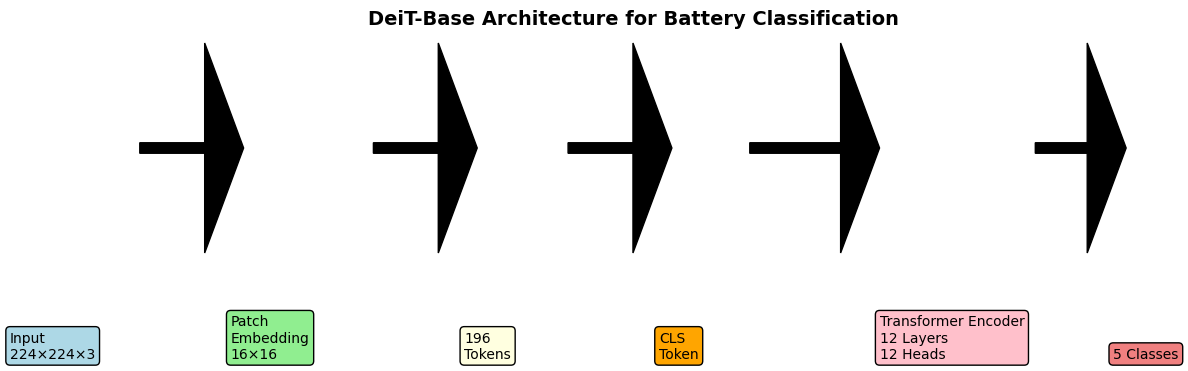

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,3))

ax.axis('off')

ax.text(0.05,0.5,'Input\n224×224×3',
        bbox=dict(boxstyle='round',facecolor='lightblue'))

ax.text(0.22,0.5,'Patch\nEmbedding\n16×16',
        bbox=dict(boxstyle='round',facecolor='lightgreen'))

ax.text(0.40,0.5,'196\nTokens',
        bbox=dict(boxstyle='round',facecolor='lightyellow'))

ax.text(0.55,0.5,'CLS\nToken',
        bbox=dict(boxstyle='round',facecolor='orange'))

ax.text(0.72,0.5,'Transformer Encoder\n12 Layers\n12 Heads',
        bbox=dict(boxstyle='round',facecolor='pink'))

ax.text(0.90,0.5,'5 Classes',
        bbox=dict(boxstyle='round',facecolor='lightcoral'))

plt.arrow(0.15,0.52,0.05,0,
          head_width=0.02,color='black')

plt.arrow(0.33,0.52,0.05,0,
          head_width=0.02,color='black')

plt.arrow(0.48,0.52,0.05,0,
          head_width=0.02,color='black')

plt.arrow(0.62,0.52,0.07,0,
          head_width=0.02,color='black')

plt.arrow(0.84,0.52,0.04,0,
          head_width=0.02,color='black')

plt.title(
    "DeiT-Base Architecture for Battery Classification",
    fontsize=14,
    fontweight="bold"
)

plt.show()

In [37]:
complexity_df = pd.DataFrame({

    "Metric":[
        "Parameters",
        "Embedding Dimension",
        "Attention Heads",
        "Transformer Blocks",
        "Patch Size",
        "Input Resolution"
    ],

    "Value":[
        "86 Million",
        768,
        12,
        12,
        "16×16",
        "224×224"
    ]
})

complexity_df

,Metric,Value
0,Parameters,86 Million
1,Embedding Dimension,768
2,Attention Heads,12
3,Transformer Blocks,12
4,Patch Size,16×16
5,Input Resolution,224×224


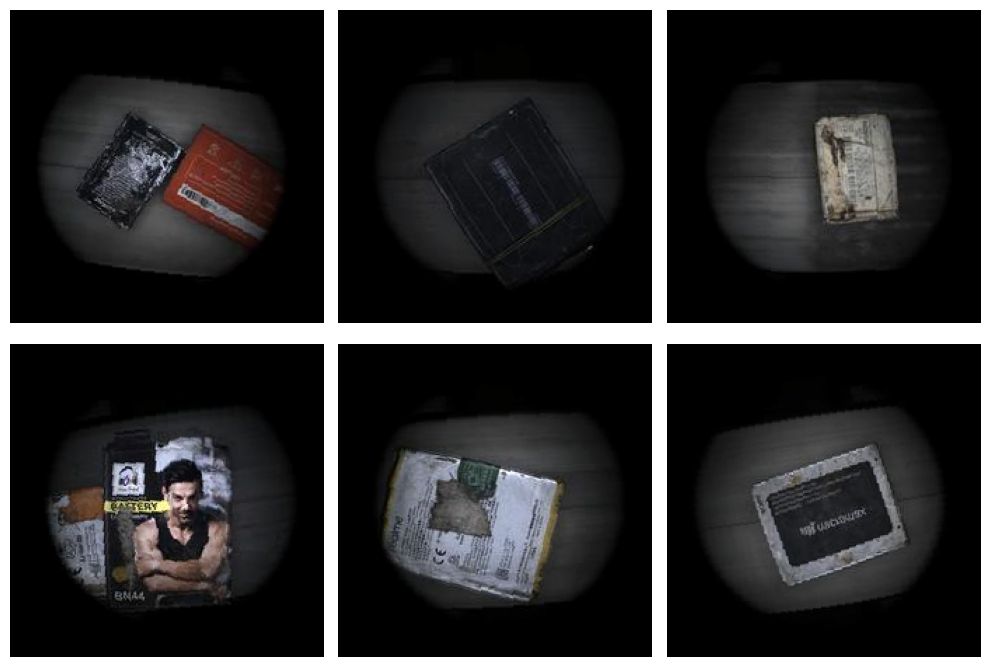

In [39]:
images, labels = next(
    iter(train_loader)
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(10,7)
)

for ax, img in zip(
    axes.flatten(),
    images[:6]
):

    img = img.permute(
        1,
        2,
        0
    )

    img = img.numpy()

    img = (
        img * np.array(
            [0.229,0.224,0.225]
        )
        +
        np.array(
            [0.485,0.456,0.406]
        )
    )

    img = np.clip(
        img,
        0,
        1
    )

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

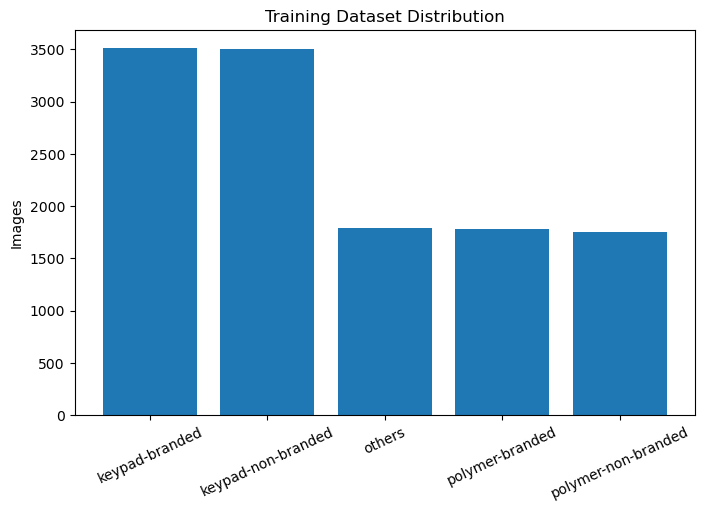

In [41]:
class_counts = pd.Series(
    train_dataset.targets
).value_counts()

plt.figure(
    figsize=(8,5)
)

plt.bar(
    train_dataset.classes,
    class_counts
)

plt.xticks(
    rotation=25
)

plt.ylabel(
    "Images"
)

plt.title(
    "Training Dataset Distribution"
)

plt.show()

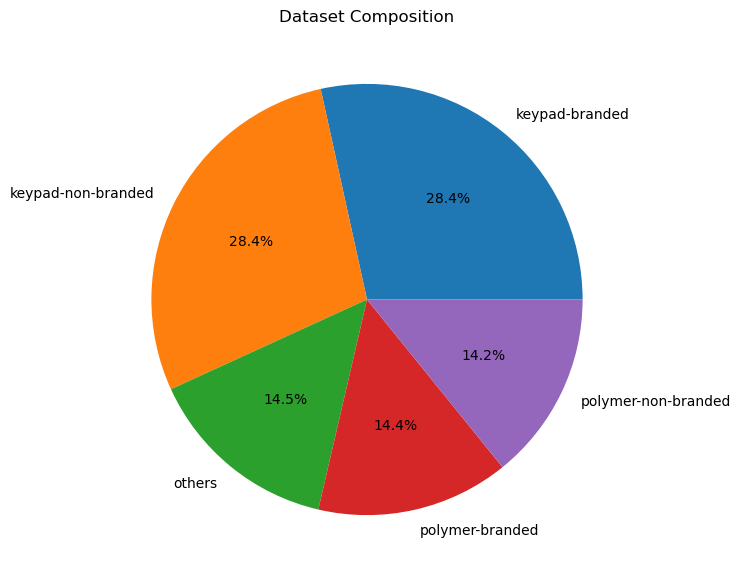

In [43]:
plt.figure(
    figsize=(7,7)
)

plt.pie(
    class_counts,
    labels=train_dataset.classes,
    autopct="%1.1f%%"
)

plt.title(
    "Dataset Composition"
)

plt.show()

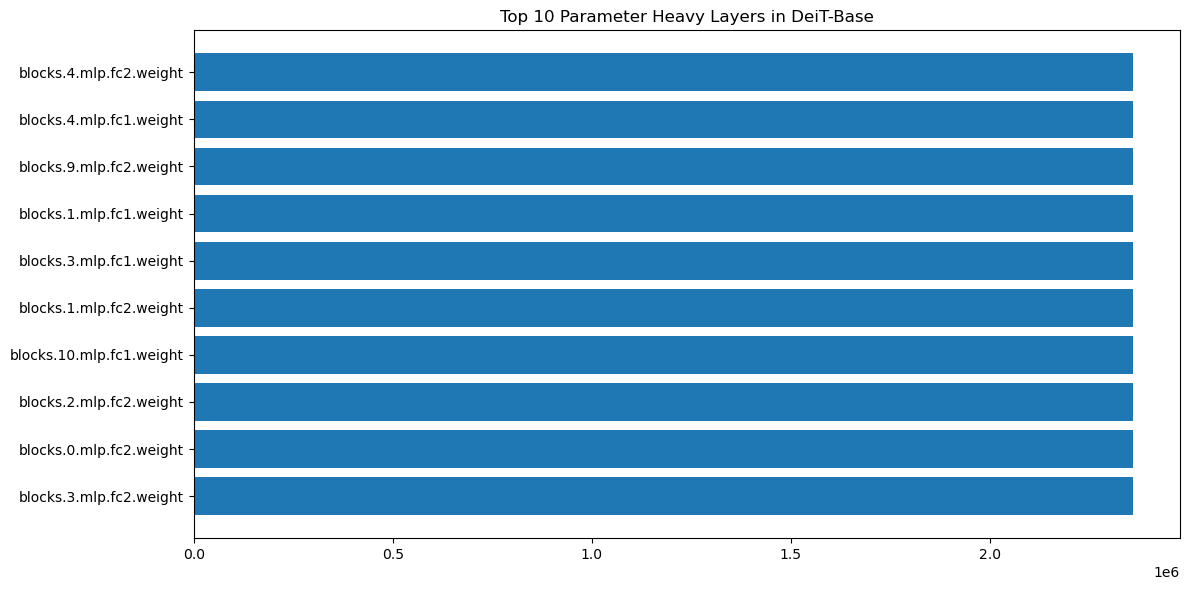

In [45]:
layer_names = []
layer_params = []

for name, param in model.named_parameters():

    layer_names.append(name)

    layer_params.append(
        param.numel()
    )

param_df = pd.DataFrame({

    "Layer":layer_names,
    "Parameters":layer_params
})

top10 = param_df.sort_values(
    by="Parameters",
    ascending=False
).head(10)

plt.figure(
    figsize=(12,6)
)

plt.barh(
    top10["Layer"],
    top10["Parameters"]
)

plt.title(
    "Top 10 Parameter Heavy Layers in DeiT-Base"
)

plt.tight_layout()

plt.show()

In [47]:
print(type(model))

<class 'timm.models.vision_transformer.VisionTransformer'>


In [49]:
total_params = sum(p.numel() for p in model.parameters())

print(f"Total Parameters: {total_params:,}")

Total Parameters: 85,802,501


In [51]:
print(model)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [53]:
dummy = torch.randn(
    1, 3, 224, 224
).to(device)

with torch.no_grad():
    output = model(dummy)

print("Output Shape:", output.shape)

Output Shape: torch.Size([1, 5])


In [57]:
if torch.cuda.is_available():

    print(
        "Allocated:",
        round(
            torch.cuda.memory_allocated()/1024**3,
            2
        ),
        "GB"
    )

    print(
        "Reserved:",
        round(
            torch.cuda.memory_reserved()/1024**3,
            2
        ),
        "GB"
    )

In [59]:
weights = torch.tensor(
    [0.7, 0.7, 1.4, 1.4, 1.4],
    dtype=torch.float32
).to(device)

print(weights)

tensor([0.7000, 0.7000, 1.4000, 1.4000, 1.4000])


In [61]:
criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=0.1
)

print("Loss Function Ready")

Loss Function Ready


In [63]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.05,
    betas=(0.9, 0.999)
)

Optimizer Ready


In [65]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

print("Scheduler Ready")

Scheduler Ready


In [67]:
from torch.amp import GradScaler

scaler = GradScaler("cuda")

AMP Enabled


/var/folders/x7/tyg5yb5172zggw01kmwk840h0000gn/T/ipykernel_70509/2000225056.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/opt/anaconda3/lib/python3.12/site-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


In [69]:
def calculate_accuracy(outputs, labels):

    preds = outputs.argmax(dim=1)

    correct = (
        preds == labels
    ).sum().item()

    return 100 * correct / labels.size(0)

In [71]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    accumulation_steps = 4

    optimizer.zero_grad(set_to_none=True)

    for batch_idx, (images, labels) in enumerate(tqdm(loader)):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss = loss / accumulation_steps

        scaler.scale(loss).backward()

        if ((batch_idx + 1) % accumulation_steps == 0) or ((batch_idx + 1) == len(loader)):

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)

            scaler.update()

            optimizer.zero_grad(set_to_none=True)

    
        running_loss += loss.item() * accumulation_steps

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        # Free GPU memory
        del images
        del labels
        del outputs
        del loss

    epoch_loss = running_loss / len(loader)

    epoch_acc = (100.0 * correct) / total

    return epoch_loss, epoch_acc

In [82]:
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda"):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

            del images
            del labels
            del outputs
            del loss

    epoch_loss = running_loss / len(loader)

    epoch_acc = (100.0 * correct) / total

    return epoch_loss, epoch_acc

In [84]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0

In [86]:
save_path = "best_deit_base.pth"

In [ ]:
import gc
import time

num_epochs = 40

best_val_acc = 0.0
patience = 7
counter = 0

for epoch in range(num_epochs):

    start_time = time.time()

    print("=" * 60)
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print("=" * 60)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Learning Rate : {current_lr:.7f}")
    print(f"Train Loss    : {train_loss:.4f}")
    print(f"Train Acc     : {train_acc:.2f}%")
    print(f"Val Loss      : {val_loss:.4f}")
    print(f"Val Acc       : {val_acc:.2f}%")

    if torch.cuda.is_available():

        print(
            f"GPU Memory : {torch.cuda.memory_allocated()/1024**3:.2f} GB"
        )

    if val_acc > best_val_acc:

        best_val_acc = val_acc
        counter = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_accuracy": best_val_acc,
            },
            save_path,
        )

        print("Best Model Saved")

    else:

        counter += 1
        print(f"No Improvement ({counter}/{patience})")

    epoch_time = time.time() - start_time

    print(f"Epoch Time : {epoch_time/60:.2f} min")

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if counter >= patience:

        print("\nEarly Stopping Triggered")

        break

print("=" * 60)
print("Training Finished")
print(f"Best Validation Accuracy : {best_val_acc:.2f}%")
print("=" * 60)